In [38]:
import numpy as np 
import torch 
import torch.nn as nn 

In [39]:
from torchvision.datasets import CIFAR10
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)  
CIFAR10_STD = (0.2023, 0.1994, 0.2010)


# Apply in your data loader with torchvision.transforms
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)
])

transformArgu = transforms.Compose([transforms.RandomCrop(size=32, padding=4), 
                                    transforms.RandomHorizontalFlip(),
                                    transforms.ToTensor(), 
                                    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)])

train_dataset = CIFAR10(
    root="./datasets",
    train=True,
    download=True,
    transform=transformArgu
)


test_dataset = CIFAR10(
    root="./datasets",
    train=False,
    download=True,
    transform=transform
)

print(len(train_dataset))
print(len(test_dataset))

50000
10000


In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class myCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=2)
        self.bn1 = nn.BatchNorm2d(32)

        self.dropout1 = nn.Dropout(0.2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=2)
        self.bn2 = nn.BatchNorm2d(64)

        self.maxpool = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(64, 64, kernel_size=3)
        self.bn3 = nn.BatchNorm2d(64)

        self.fc1 = nn.Linear(16384, 128)
        self.bn4 = nn.BatchNorm1d(128)

        # self.dropout_fc = nn.Dropout(0.5)

        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.maxpool(x)
        x = self.dropout1(x)

        x = F.relu(self.bn3(self.conv3(x)))

        x = torch.flatten(x, 1)

        x = F.relu(self.bn4(self.fc1(x)))
        # x = self.dropout_fc(x)

        x = self.fc2(x)

        return x

In [41]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size = 64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle=True)


In [42]:
model = myCNN()
device = "cuda"
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)

def accuracy(loader): 
    model.eval()
    
    correct = 0 ; total = 0 

    with torch.no_grad():
        for img, label in loader: 

            img = img.to(device)
            label = label.to(device)

            yhat = model(img)
            yhat = torch.argmax(yhat, dim=1)
            correct += (label == yhat).sum().item()

            total += len(yhat)

        return 100 * (correct/total)

def evaluate_loss(loader):
    model.eval()
    total_loss = 0
    total_samples = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            loss = loss_fn(outputs, y)

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

    model.train()
    return total_loss / total_samples

In [ ]:
import time
import torch

epochs = 100
patience = 6
counter = 0
best_val_loss = float('inf')

loss_rec = []
test_loss_rec = []
accuracy_rec_test = []
accuracy_rec_train = []

model = model.to(device)

for epoch in range(epochs):

    s = time.time()
    model.train()
    train_loss = 0
 
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        outputs = model(x)
        loss = loss_fn(outputs, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
 
    val_loss = evaluate_loss(test_loader)
 
    train_acc = accuracy(train_loader)
    test_acc = accuracy(test_loader)
 
    loss_rec.append(train_loss)
    test_loss_rec.append(val_loss)
    accuracy_rec_train.append(train_acc)
    accuracy_rec_test.append(test_acc)

    epoch_time = time.time() - s

    print(
        f"Epoch : {epoch+1} || "
        f"Train Loss : {train_loss:.4f} || "
        f"Val Loss : {val_loss:.4f} || "
        f"Train Acc : {train_acc:.2f} || "
        f"Test Acc : {test_acc:.2f} || "
        f"Time : {epoch_time:.2f}s"
    )
 
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("Validation improved → model saved")
    else:
        counter += 1
        print(f"No improvement ({counter}/{patience})")

        if counter >= patience:
            for param_group in optimizer.param_groups:
                param_group['lr'] /= 10

Epoch : 1 || Train Loss : 1.5218 || Val Loss : 1.1763 || Train Acc : 54.87 || Test Acc : 58.22 || Time : 26.80s
Validation improved → model saved
Epoch : 2 || Train Loss : 1.1913 || Val Loss : 0.9740 || Train Acc : 61.17 || Test Acc : 65.20 || Time : 24.54s
Validation improved → model saved
Epoch : 3 || Train Loss : 1.0582 || Val Loss : 0.8693 || Train Acc : 66.23 || Test Acc : 70.05 || Time : 24.40s
Validation improved → model saved
Epoch : 4 || Train Loss : 0.9798 || Val Loss : 0.8287 || Train Acc : 67.68 || Test Acc : 70.71 || Time : 24.52s
Validation improved → model saved
Epoch : 5 || Train Loss : 0.9203 || Val Loss : 0.8120 || Train Acc : 69.02 || Test Acc : 71.38 || Time : 25.02s
Validation improved → model saved
Epoch : 6 || Train Loss : 0.8772 || Val Loss : 0.7752 || Train Acc : 70.25 || Test Acc : 72.62 || Time : 25.17s
Validation improved → model saved


In [ ]:
print("\nLoss Rec : ", loss_rec, 
    "\nTest Loss : ", test_loss_rec, 
    "\nAccuracy Train : ", accuracy_rec_train, 
    "\nAccuracy Test : " , accuracy_rec_test)


Loss Rec :  [1.5287230159620495, 1.2186870006344201, 1.077696100906338, 0.993514933778197, 0.9376840292645232, 0.8922313928909009, 0.8520586241389174, 0.8165672846767299, 0.7942006057485596, 0.7634923337670543, 0.7544807404508371, 0.7255545599609995, 0.7095532229032053, 0.6949289235312616, 0.6800360455918495, 0.6667453153892551, 0.6529801645318566, 0.642914513873932, 0.6285653746570162, 0.6171040089843828, 0.608955711774204, 0.5987086411556015, 0.5892742384806313, 0.5779371637746197, 0.5667027207019993, 0.5627873324600937, 0.5581677874640736, 0.5523988266887567, 0.5398272724865038, 0.533540304893118, 0.5305315933340345, 0.5231726221416307, 0.5183051592477447] 
Test Loss :  [1.1951664937973023, 1.0111924396514893, 0.9366534381866455, 0.8932486603736878, 0.8037908308506012, 0.7920211144447327, 0.7327026681900024, 0.7667845297813416, 0.7024350435256957, 0.6676541912078857, 0.6443086927890778, 0.6652813142776489, 0.6420185260772705, 0.6389409648895263, 0.6280307223320007, 0.60761863784790

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns 

ValueError: x and y must have same first dimension, but have shapes (17,) and (33,)

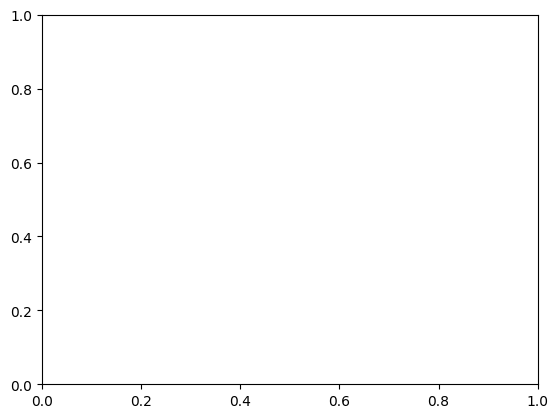

In [ ]:
e = np.arange(17) + 1 
plt.plot(e, loss_rec, label= "Train Loss")
plt.plot(e, test_loss_rec, label = "Test Loss")
plt.xlabel("epochs")
plt.ylabel("loss")

plt.legend()
plt.show()

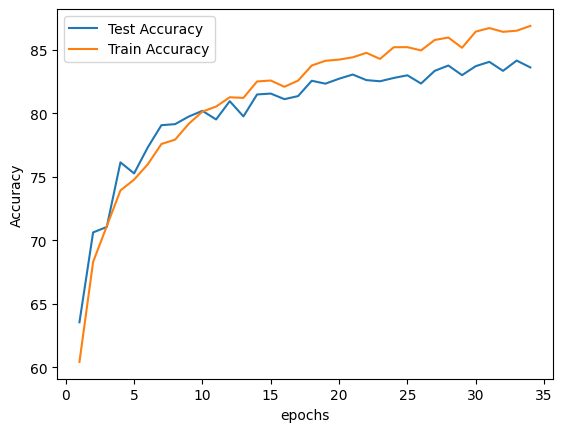

In [ ]:
e = np.arange(34) + 1 
plt.plot(e, accuracy_rec_test, label= "Test Accuracy")
plt.plot(e, accuracy_rec_train, label = "Train Accuracy")
plt.xlabel("epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

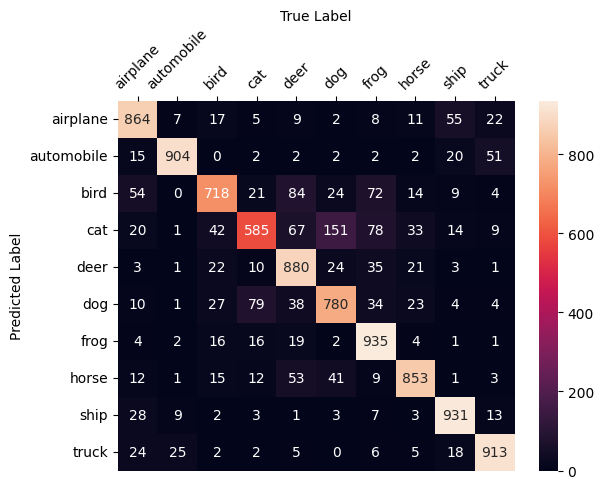

In [ ]:
import sklearn 
from sklearn.metrics import confusion_matrix

classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

y_hat = []
y_true = []

with torch.no_grad(): 
    for images, labels in test_loader: 

        images = images.to("cuda")
        labels = labels.to("cuda")

        y_hat_batch = torch.argmax(model(images), dim=1)
        y_true_batch = labels 

        y_hat.extend(y_hat_batch.cpu().numpy())
        y_true.extend(y_true_batch.cpu().numpy())




cnf_mat = confusion_matrix(y_pred=y_hat , y_true=y_true)

ax = sns.heatmap(cnf_mat,xticklabels=classes, yticklabels=classes, annot=True, fmt='d')
plt.ylabel("Predicted Label")
plt.xlabel("True Label")
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()